# Advanced DenseNet121 Lung Cancer Detection

In [1]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [2]:

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15

dataset_path = '.'


In [3]:

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    classes=['lung_aca', 'lung_n', 'lung_scc'],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = val_gen.flow_from_directory(
    dataset_path,
    classes=['lung_aca', 'lung_n', 'lung_scc'],
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 1920 images belonging to 3 classes.
Found 480 images belonging to 3 classes.


In [4]:

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,694,403 (29.35 MB)

 Trainable params: 656,899 (2.51 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [5]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [6]:

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_densenet_model.keras',
        save_best_only=True
    )
]


In [7]:

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights if 'class_weights' in globals() else None
)


Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.7635 - loss: 0.5858 - val_accuracy: 0.9167 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.8781 - loss: 0.2977 - val_accuracy: 0.9292 - val_loss: 0.1788 - learning_rate: 0.0010
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8938 - loss: 0.2447 - val_accuracy: 0.9167 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9021 - loss: 0.2460 - val_accuracy: 0.9396 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9083 - loss: 0.2237 - val_accuracy: 0.9375 - val_loss: 0.1628 - learning_rate: 0.0010
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.9109 - loss: 0.2206 - val_accuracy: 0.9354 - val_loss: 0.1602 - learning_rate: 0.0010
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 2505s 21s/step - accuracy: 0.9104 - loss: 

In [8]:

# Reset validation generator before prediction
val_data.reset()

predictions = model.predict(val_data)

y_pred = np.argmax(predictions, axis=1)
y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step
              precision    recall  f1-score   support

    lung_aca       0.90      0.93      0.92       160
      lung_n       1.00      1.00      1.00       160
    lung_scc       0.93      0.90      0.91       160

    accuracy                           0.94       480
   macro avg       0.94      0.94      0.94       480
weighted avg       0.94      0.94      0.94       480



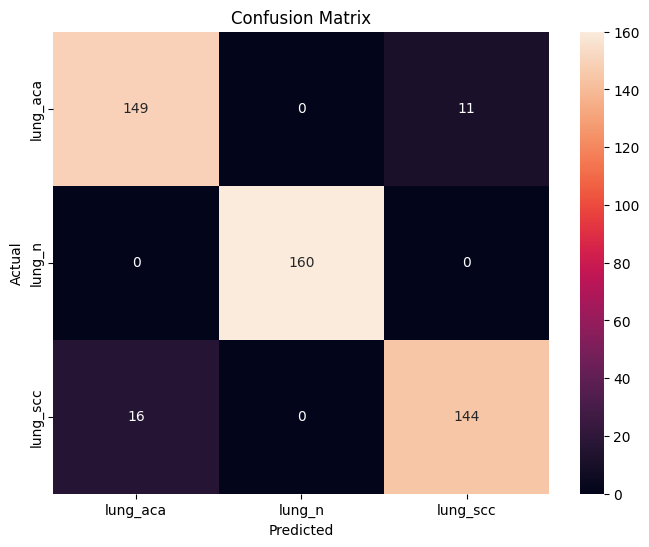

In [9]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


In [10]:

model.save('advanced_densenet_lung_model.keras')

print("Model saved successfully.")


Model saved successfully.
